# EDA — Alfabetização municipal (Tech Challenge Fase 3)

Unidade de análise: **município × ano** (2023, 2024). Target: `atingiu_meta` = o município atingiu a própria meta oficial de alfabetização do INEP naquele ano (`taxa_alfabetizacao >= meta_alfabetizacao_2024`).

Esta EDA apoia diretamente as decisões da modelagem: quais variáveis entram como feature, que transformações elas precisam, e que hipóteses testar.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
IMAGES_DIR = Path("../images")
IMAGES_DIR.mkdir(exist_ok=True)

df = pd.read_parquet("../data/processed/municipio_alfabetizacao_enriquecido.parquet")
df.shape

(9921, 21)

In [2]:
df.dtypes

ano                                   Int64
id_municipio                            str
nome_municipio                          str
sigla_uf                                str
nome_uf                                 str
nome_regiao                             str
nome_mesorregiao                        str
capital_uf                            Int64
amazonia_legal                        Int64
populacao                             Int64
pib                                   Int64
taxa_aprovacao_ef_anos_iniciais     float64
taxa_reprovacao_ef_anos_iniciais    float64
taxa_abandono_ef_anos_iniciais      float64
tdi_ef_anos_iniciais                float64
atu_ef_anos_iniciais                float64
dsu_ef_anos_iniciais                float64
taxa_alfabetizacao                  float64
media_portugues                     float64
meta_alfabetizacao_2024             float64
atingiu_meta                          Int64
dtype: object

In [3]:
nulos = df.isnull().sum()
nulos[nulos > 0]

tdi_ef_anos_iniciais     1
atu_ef_anos_iniciais     1
dsu_ef_anos_iniciais    17
dtype: int64

Nulos residuais em 3 colunas educacionais, sempre abaixo de 0,2% das linhas (`tdi_ef_anos_iniciais`, `atu_ef_anos_iniciais`, `dsu_ef_anos_iniciais`). Não é um problema de qualidade — a imputação (mediana) dentro do `Pipeline` sklearn resolve sem necessidade de tratamento especial.

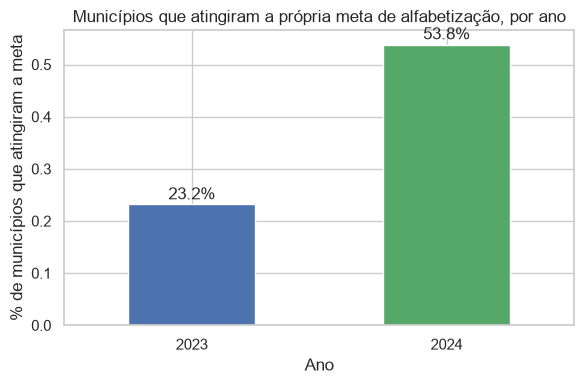

ano
2023    0.231606
2024    0.538417
Name: atingiu_meta, dtype: Float64

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
taxa_por_ano = df.groupby("ano")["atingiu_meta"].mean()
taxa_por_ano.plot(kind="bar", ax=ax, color=["#4C72B0", "#55A868"])
ax.set_ylabel("% de municípios que atingiram a meta")
ax.set_xlabel("Ano")
ax.set_title("Municípios que atingiram a própria meta de alfabetização, por ano")
for i, v in enumerate(taxa_por_ano):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center")
ax.set_xticklabels(["2023", "2024"], rotation=0)
plt.tight_layout()
plt.savefig(IMAGES_DIR / "01_target_por_ano.png", dpi=120)
plt.show()
taxa_por_ano

Salto grande: 23,2% dos municípios atingiram a meta em 2023 contra 53,8% em 2024. Antes de assumir que é uma melhora real, checamos se a própria meta mudou entre os dois anos — se a meta tivesse caído, o salto seria um artefato, não uma melhora genuína.

In [5]:
resumo = df.groupby("ano")[["taxa_alfabetizacao", "meta_alfabetizacao_2024"]].mean().round(2)
resumo.columns = ["taxa_alfabetizacao (média)", "meta_alfabetizacao_2024 (média)"]
resumo

,taxa_alfabetizacao (média),meta_alfabetizacao_2024 (média)
ano,,
2023,60.59,61.97
2024,63.52,62.15


**Insight confirmado:** a meta média ficou praticamente igual entre os dois anos (61,97 em 2023 vs 62,15 em 2024 — variação de 0,3 ponto). Quem mudou foi a taxa de alfabetização real, que subiu de 60,59 para 63,52 em média. O salto no target não é um artefato de meta mais fácil — é melhora real na taxa de alfabetização mensurada, o que é uma boa notícia para a narrativa do vídeo executivo (o indicador está melhorando, não estagnado).

In [6]:
df[["taxa_alfabetizacao", "media_portugues"]].corr()

,taxa_alfabetizacao,media_portugues
taxa_alfabetizacao,1.000000,0.926638
media_portugues,0.926638,1.000000


**Confirmação empírica da decisão de vazamento de dado:** `taxa_alfabetizacao` e `media_portugues` têm correlação de **0,93** — vêm essencialmente do mesmo processo de avaliação que gerou o target. Junto com `meta_alfabetizacao_2024` (que define o target por construção), essas 3 colunas ficam no dataset só como referência/auditoria e **são excluídas do conjunto de features (X)** antes de qualquer treinamento. As features reais do modelo são só as territoriais, populacionais, de PIB e educacionais complementares.

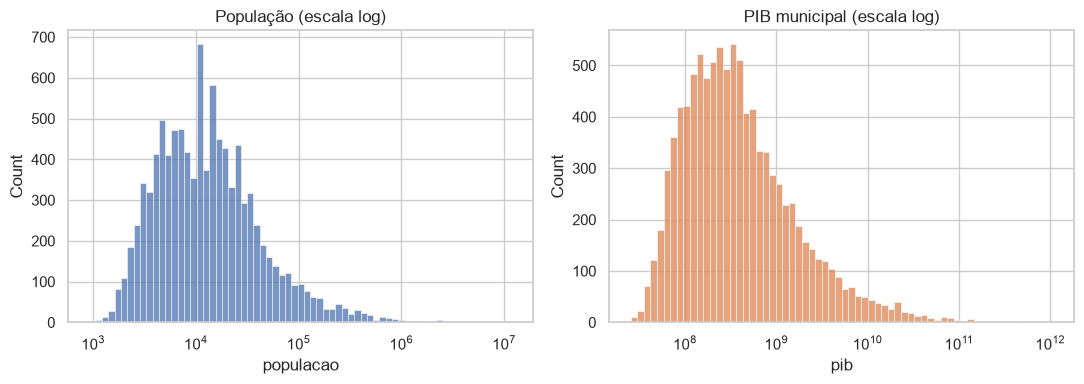

,populacao,pib
count,9921.0,9921.0
mean,37600.874206,1895097138.090918
std,218617.642576,17510009479.818069
min,921.0,25284000.0
25%,5470.0,136099000.0
50%,11438.0,310142000.0
75%,25090.0,823511000.0
max,11895578.0,1066825105000.0


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df["populacao"], log_scale=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("População (escala log)")
sns.histplot(df["pib"], log_scale=True, ax=axes[1], color="#DD8452")
axes[1].set_title("PIB municipal (escala log)")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "02_distribuicao_populacao_pib.png", dpi=120)
plt.show()
df[["populacao", "pib"]].describe()

`populacao` e `pib` são fortemente assimétricos (mediana de população = 11.438 habitantes, média = 37.601 — puxada por poucos municípios muito grandes, até 11,9 milhões). Decisão: aplicar transformação log (ou usar `RobustScaler`) nessas duas colunas dentro do pipeline, em vez de `StandardScaler` direto, que seria distorcido pelos outliers de tamanho.

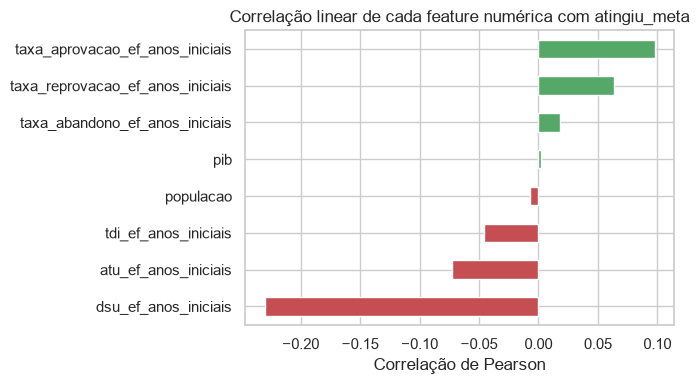

dsu_ef_anos_iniciais               -0.230327
atu_ef_anos_iniciais               -0.072414
tdi_ef_anos_iniciais               -0.045503
populacao                          -0.007026
pib                                 0.002472
taxa_abandono_ef_anos_iniciais      0.018096
taxa_reprovacao_ef_anos_iniciais    0.063504
taxa_aprovacao_ef_anos_iniciais     0.097593
Name: atingiu_meta, dtype: float64

In [8]:
num_cols = [
    "populacao", "pib",
    "taxa_aprovacao_ef_anos_iniciais", "taxa_reprovacao_ef_anos_iniciais", "taxa_abandono_ef_anos_iniciais",
    "tdi_ef_anos_iniciais", "atu_ef_anos_iniciais", "dsu_ef_anos_iniciais",
]
corrs = df[num_cols + ["atingiu_meta"]].corr()["atingiu_meta"].drop("atingiu_meta").sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
corrs.plot(kind="barh", ax=ax, color=["#C44E52" if v < 0 else "#55A868" for v in corrs])
ax.set_title("Correlação linear de cada feature numérica com atingiu_meta")
ax.set_xlabel("Correlação de Pearson")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "03_correlacao_features_target.png", dpi=120)
plt.show()
corrs

Todas as correlações lineares são fracas (máximo ≈ 0,23, em `dsu_ef_anos_iniciais`, e negativa — municípios com mais professores com curso superior tendendo a ter *menor* taxa de atingimento da meta, o que é contraintuitivo e merece nota como limitação, não uma causalidade). `populacao` e `pib` têm correlação linear praticamente nula com o target (0,00 e 0,00). **Hipótese para a modelagem:** o sinal preditivo real provavelmente não é linear/individual por variável — vem mais de padrões regionais e de interações entre variáveis do que de qualquer feature numérica isolada. Isso pesa a favor de usar modelos baseados em árvore (Random Forest / Gradient Boosting), que capturam não-linearidade e interação, em vez de confiar só numa Regressão Logística.

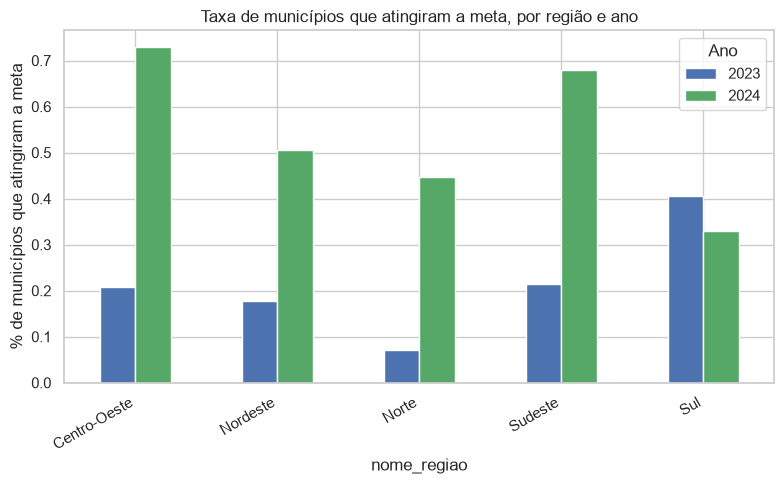

ano,2023,2024
nome_regiao,,
Centro-Oeste,0.208,0.729
Nordeste,0.178,0.505
Norte,0.072,0.447
Sudeste,0.215,0.68
Sul,0.405,0.33


In [9]:
regiao_ano = df.groupby(["nome_regiao", "ano"])["atingiu_meta"].mean().unstack()
fig, ax = plt.subplots(figsize=(8, 5))
regiao_ano.plot(kind="bar", ax=ax, color=["#4C72B0", "#55A868"])
ax.set_ylabel("% de municípios que atingiram a meta")
ax.set_title("Taxa de municípios que atingiram a meta, por região e ano")
ax.legend(title="Ano")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "04_regiao_ano.png", dpi=120)
plt.show()
regiao_ano.round(3)

Evolução bem assimétrica entre regiões: Centro-Oeste (21%→73%), Sudeste (22%→68%), Nordeste (18%→51%) e Norte (7%→45%) melhoraram muito. A região **Sul é a única que piorou** (41%→33%). Olhando por UF (célula seguinte), o Rio Grande do Sul aparece como o pior estado do país em 2024 (8,3% de municípios atingindo a meta, ante uma média nacional de 53,8%) — uma queda muito acentuada e isolada.

**Hipótese a registrar no README (não comprovada com os dados que temos, mas relevante para a interpretação de negócio):** o ciclo letivo de 2024 no Rio Grande do Sul foi marcado pelas enchentes históricas de abril-maio de 2024, que fecharam ou danificaram um número muito grande de escolas no estado. É plausível que esse choque exógeno explique parte da queda isolada do RS, e não uma piora estrutural do sistema educacional gaúcho. Isso é uma limitação importante do modelo: nenhuma das nossas features captura eventos climáticos/exógenos de um ano específico — o modelo vai aprender o padrão histórico, não choques pontuais.

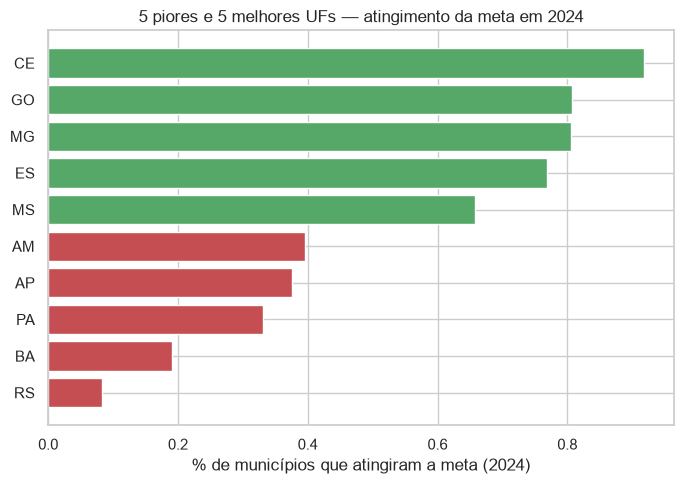

,count,mean
sigla_uf,,
RS,421,0.083135
BA,394,0.190355
PA,136,0.330882
AP,16,0.375
AM,48,0.395833
MS,79,0.658228
ES,78,0.769231
MG,801,0.805243
GO,243,0.806584


In [10]:
uf_2024 = df[df.ano == 2024].groupby("sigla_uf")["atingiu_meta"].agg(["count", "mean"]).sort_values("mean")
top_bottom = pd.concat([uf_2024.head(5), uf_2024.tail(5)])
fig, ax = plt.subplots(figsize=(7, 5))
colors = ["#C44E52"] * 5 + ["#55A868"] * 5
ax.barh(top_bottom.index, top_bottom["mean"], color=colors)
ax.set_xlabel("% de municípios que atingiram a meta (2024)")
ax.set_title("5 piores e 5 melhores UFs — atingimento da meta em 2024")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "05_top_bottom_uf_2024.png", dpi=120)
plt.show()
top_bottom

In [11]:
print("Capitais vs. não-capitais:")
print(df.groupby("capital_uf")["atingiu_meta"].agg(["count", "mean"]))
print("\nAmazônia Legal vs. resto do país:")
print(df.groupby("amazonia_legal")["atingiu_meta"].agg(["count", "mean"]))

Capitais vs. não-capitais:
            count      mean
capital_uf                 
0            9879  0.393866
1              42  0.285714

Amazônia Legal vs. resto do país:
                count      mean
amazonia_legal                 
0                8505  0.406937
1                1416  0.312147


Diferenças moderadas: capitais atingem a meta menos que o interior (28,6% vs 39,4%) e municípios da Amazônia Legal também ficam abaixo da média (31,2% vs 40,7%). Sinal mais fraco que região/UF, mas coerente com desigualdades educacionais já documentadas na literatura — mantemos como features categóricas de baixo custo.

In [12]:
pib_per_capita = df["pib"] / df["populacao"]
print("Correlação pib_per_capita x atingiu_meta:", round(pib_per_capita.corr(df["atingiu_meta"]), 4))
pib_per_capita.describe()

Correlação pib_per_capita x atingiu_meta: 0.0004


count           9921.0
mean      38880.847353
std       39542.363765
min        6840.996526
25%       16138.737068
50%       28135.747114
75%       48201.830283
max      722441.518999
dtype: Float64

## Exploração adicional (achados abertos, sem conclusão fechada)

As análises acima já dão o suficiente para começar a modelagem. As células a seguir são um esforço extra de exploração — testam hipóteses razoáveis, mas nem todas fecham numa conclusão firme. Deixamos isso registrado porque também é evidência de que investigamos a fundo (e não inventamos explicação onde os dados não sustentam), não porque toda pergunta precisa ter resposta.

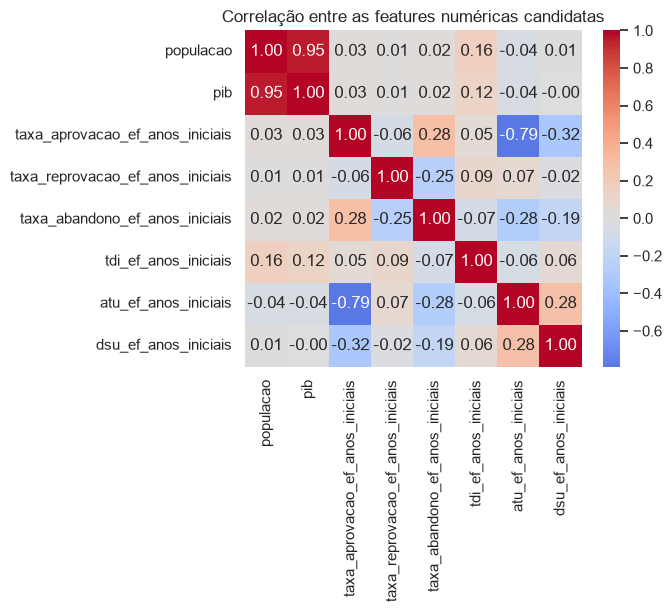

In [13]:
fig, ax = plt.subplots(figsize=(7, 6))
corr_matrix = df[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, square=True)
ax.set_title("Correlação entre as features numéricas candidatas")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "06_correlacao_features.png", dpi=120)
plt.show()

**Multicolinearidade encontrada:** `populacao` e `pib` têm correlação de **0,95** entre si — praticamente a mesma informação. Isso não é surpresa (município maior tende a ter PIB total maior, mesmo sem ser mais rico per capita), mas é algo a decidir na modelagem: manter as duas colunas é arriscado para um modelo linear (Regressão Logística), mas não é problema para os modelos baseados em árvore (Random Forest/Gradient Boosting não perdem estabilidade com colinearidade). Decisão: manter as duas, mas monitorar a importância relativa delas no modelo campeão — se as duas aparecerem com importância baixa e redundante, cortamos uma no relatório final.

As taxas educacionais (`taxa_aprovacao`, `taxa_reprovacao`, `taxa_abandono`) têm correlações fracas entre si (|r| entre 0,06 e 0,28) — não são redundantes como se poderia supor à primeira vista, então faz sentido manter as três.

C:\Users\win\AppData\Local\Temp\ipykernel_20680\1940143446.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="pop_quartil", y="taxa_alfabetizacao", ax=ax, palette="Blues")


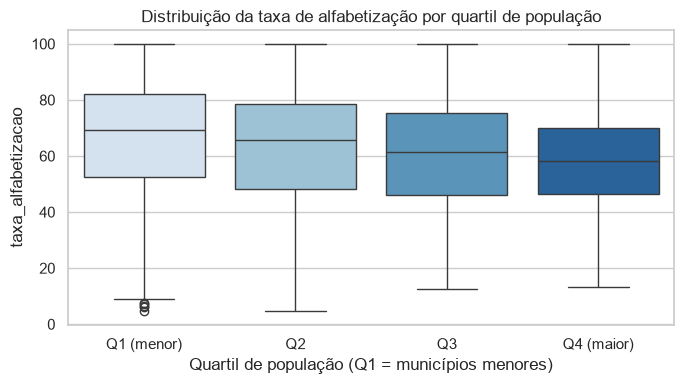

,count,mean,std
pop_quartil,,,
Q1 (menor),2481,66.27,20.47
Q2,2480,63.27,19.92
Q3,2480,60.69,19.34
Q4 (maior),2480,58.29,16.97


In [14]:
df["pop_quartil"] = pd.qcut(df["populacao"], 4, labels=["Q1 (menor)", "Q2", "Q3", "Q4 (maior)"])
resumo_pop = df.groupby("pop_quartil", observed=True)["taxa_alfabetizacao"].agg(["count", "mean", "std"]).round(2)

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df, x="pop_quartil", y="taxa_alfabetizacao", ax=ax, palette="Blues")
ax.set_title("Distribuição da taxa de alfabetização por quartil de população")
ax.set_xlabel("Quartil de população (Q1 = municípios menores)")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "07_taxa_por_quartil_populacao.png", dpi=120)
plt.show()
resumo_pop

**Hipótese testada: municípios pequenos têm taxa mais "ruidosa" por causa do tamanho pequeno da amostra de alunos avaliados.** O desvio-padrão de `taxa_alfabetizacao` cai de forma consistente conforme o município cresce (Q1: 20,47 → Q2: 19,92 → Q3: 19,34 → Q4: 16,97), o que é compatível com a hipótese: quanto menos alunos um município tem, mais a taxa (que é basicamente uma proporção sobre poucos casos) oscila para os extremos. Isso é um fenômeno estatístico conhecido em dados de avaliação educacional (às vezes chamado de "efeito das escolas pequenas").

**Mas não é conclusivo** — os municípios menores (Q1) também têm a **média mais alta** (66,27 contra 58,29 no Q4), não só mais variância. Isso pode ser: (a) só coincidência estatística dessa amostra específica; (b) um efeito real de escala (turmas menores, mais atenção individual); ou (c) confundido com região (municípios pequenos não estão distribuídos igualmente entre regiões). Não temos como separar essas explicações só com EDA — fica registrado como pergunta em aberto, não como conclusão. Vale testar na modelagem se uma interação população×região capta isso melhor, sem forçar uma explicação causal única no relatório final.

In [15]:
extremos_baixo = df[df["taxa_alfabetizacao"] < 15]
extremos_alto = df[df["taxa_alfabetizacao"] == 100]

print(f"Municípios com taxa < 15%: {len(extremos_baixo)} — população mediana: {extremos_baixo['populacao'].median():.0f}")
print(f"Municípios com taxa = 100%: {len(extremos_alto)} — população mediana: {extremos_alto['populacao'].median():.0f}")
print(f"População mediana geral do dataset: {df['populacao'].median():.0f}")

print("\n5 menores taxas do dataset:")
print(extremos_baixo.sort_values("taxa_alfabetizacao")[["nome_municipio", "sigla_uf", "populacao", "taxa_alfabetizacao"]].head(5).to_string(index=False))

Municípios com taxa < 15%: 42 — população mediana: 6046
Municípios com taxa = 100%: 103 — população mediana: 3938
População mediana geral do dataset: 11438

5 menores taxas do dataset:
  nome_municipio sigla_uf  populacao  taxa_alfabetizacao
   Recursolândia       TO       3421                4.56
        Macururé       BA       7256                4.65
Chapada de Areia       TO       1563                6.25
      Pau D'Arco       TO       4043                6.51
  Lagoa do Piauí       PI       4810                7.17


Isso reforça a hipótese da célula anterior: tanto os **piores** quanto os **melhores** resultados absolutos (taxa < 15% e taxa = 100%) se concentram em municípios com população bem abaixo da mediana do dataset (11.438 habitantes) — inclusive vários municípios do Tocantins entre as piores taxas. Municípios muito pequenos avaliam poucos alunos, então um punhado de provas já empurra a taxa para 0% ou 100%.

**Implicação prática para a modelagem e para o vídeo:** o modelo (e qualquer dashboard construído em cima dele) deve ser interpretado com cautela para municípios muito pequenos — uma previsão "de risco" para uma cidade de 1.500 habitantes carrega mais incerteza estatística do que a mesma previsão para uma cidade de 200 mil. Não vamos resolver isso no pipeline (seria complexidade desnecessária para o escopo), mas é uma limitação real que entra na seção de limitações do relatório final.

In [16]:
print("Correlação de dsu_ef_anos_iniciais com atingiu_meta, dentro de cada região (checando se é confundimento regional):\n")
for regiao, g in df.groupby("nome_regiao", observed=True):
    corr = g["dsu_ef_anos_iniciais"].corr(g["atingiu_meta"])
    print(f"{regiao:<15} corr={corr:+.3f}   (n={len(g)}, média dsu={g['dsu_ef_anos_iniciais'].mean():.1f}%)")

Correlação de dsu_ef_anos_iniciais com atingiu_meta, dentro de cada região (checando se é confundimento regional):

Centro-Oeste    corr=-0.183   (n=922, média dsu=15.7%)
Nordeste        corr=-0.268   (n=3476, média dsu=25.7%)
Norte           corr=-0.059   (n=778, média dsu=28.9%)
Sudeste         corr=-0.176   (n=2637, média dsu=14.4%)
Sul             corr=-0.148   (n=2108, média dsu=15.5%)


**Pergunta em aberto, deixada sem resposta forçada.** Na EDA principal, `dsu_ef_anos_iniciais` (% de docentes com curso superior) apareceu com correlação negativa com o target — contraintuitivo, já que mais formação docente deveria, a princípio, ajudar. Testamos se isso era só um confundimento regional (ex.: se regiões com pior desempenho também tivessem, por acaso, mais professores com curso superior). **Não é o caso**: a correlação continua negativa em todas as 5 regiões (entre -0,06 no Norte e -0,27 no Nordeste), então não é simplesmente "região X tem mais dsu e também é pior".

Não temos uma explicação causal para isso e **não vamos inventar uma para o README ou o vídeo**. Possibilidades honestas que não conseguimos testar com os dados disponíveis: pode ser um artefato da forma como o indicador é calculado, pode reflitir que municípios com mais professores formados também são municípios que atraem professores por outros motivos correlacionados com desempenho pior (ex.: municípios maiores/mais urbanos, que vimos acima terem taxa média mais baixa), ou pode ser ruído. Fica registrado como observação, não como causa-efeito.

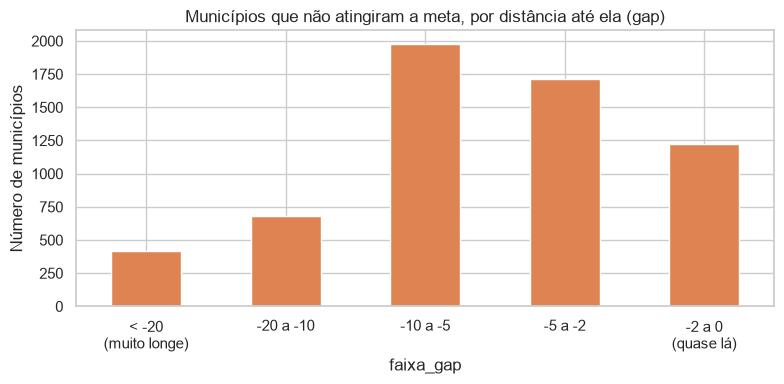

Total de municípios que não atingiram a meta: 6018
Desses, 'quase lá' (gap entre -2 e 0 pontos): 1225 (20.4%)


In [17]:
faltantes = df[df["atingiu_meta"] == 0].copy()
faltantes["gap"] = faltantes["taxa_alfabetizacao"] - faltantes["meta_alfabetizacao_2024"]

bins = [-100, -20, -10, -5, -2, 0]
labels = ["< -20\n(muito longe)", "-20 a -10", "-10 a -5", "-5 a -2", "-2 a 0\n(quase lá)"]
faltantes["faixa_gap"] = pd.cut(faltantes["gap"], bins=bins, labels=labels)
contagem = faltantes["faixa_gap"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
contagem.plot(kind="bar", ax=ax, color="#DD8452")
ax.set_ylabel("Número de municípios")
ax.set_title("Municípios que não atingiram a meta, por distância até ela (gap)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(IMAGES_DIR / "08_gap_ate_meta.png", dpi=120)
plt.show()

quase_la = (faltantes["gap"] >= -2).sum()
print(f"Total de municípios que não atingiram a meta: {len(faltantes)}")
print(f"Desses, 'quase lá' (gap entre -2 e 0 pontos): {quase_la} ({quase_la/len(faltantes):.1%})")

**Achado concreto e útil para negócio (esse aqui fecha, sem ressalva):** dos 6.018 municípios que não bateram a meta, **1.225 (20,4%) estão "quase lá"** — a menos de 2 pontos percentuais da própria meta. Isso responde de forma direta a uma das 5 perguntas do enunciado ("como prever municípios que podem não atingir metas futuras"): esses ~1.200 municípios são candidatos naturais a uma política de intervenção de baixo custo/alto impacto, porque um empurrão pequeno já tira boa parte deles da faixa de risco — diferente dos 420 municípios a mais de 20 pontos de distância, que provavelmente precisam de intervenção estrutural bem mais profunda. Essa segmentação por tamanho do gap é um insight que vai direto para a seção de aplicação em políticas públicas do README, independente de qual modelo acabarmos usando.

In [18]:
soma = (df["taxa_aprovacao_ef_anos_iniciais"]
        + df["taxa_reprovacao_ef_anos_iniciais"]
        + df["taxa_abandono_ef_anos_iniciais"])
print("Soma aprovação + reprovação + abandono (esperaríamos ~100 se fossem mutuamente exclusivas):")
print(soma.describe().round(1))

Soma aprovação + reprovação + abandono (esperaríamos ~100 se fossem mutuamente exclusivas):
count    9921.0
mean      122.8
std        20.1
min        19.8
25%       113.6
50%       126.8
75%       135.8
max       189.3
dtype: float64


**Achado que não fechamos, registrado por transparência.** A soma das três taxas educacionais fica em torno de 123% em média (variando de ~20% a ~189%), não perto de 100% como seria intuitivo se fossem categorias mutuamente exclusivas de um mesmo grupo de alunos. Investigamos as correlações entre elas (célula do heatmap acima: todas fracas, |r| entre 0,06 e 0,28) e não encontramos indício óbvio de erro de join ou duplicação da nossa parte.

Não sabemos a metodologia exata do INEP para o cálculo dessas taxas por trás dos bastidores (provavelmente usam bases/denominadores diferentes por indicador, ou contam alunos de anos-série diferentes dentro de "anos iniciais"), e não vamos especular além disso no README. **Decisão prática:** isso não nos impede de usar as três como features independentes — não achamos redundância problemática — mas registramos a limitação de não sabermos explicar 100% da metodologia da fonte, em vez de inventar uma explicação.

## Hipóteses analíticas consolidadas

**Decisões com evidência firme:**

1. **Excluir do X**: `taxa_alfabetizacao`, `media_portugues`, `meta_alfabetizacao_2024` (vazamento de dado, confirmado empiricamente — correlação de 0,93 entre `taxa_alfabetizacao` e `media_portugues`).
2. **Transformar**: `populacao` e `pib` são fortemente assimétricos — usar log-transform ou `RobustScaler`, não `StandardScaler` puro.
3. **Geografia importa mais que riqueza/tamanho**: `populacao` e `pib` têm correlação linear ≈ 0 com o target; `nome_regiao`/`sigla_uf` mostram variação enorme (RS caiu para 8,3% em 2024 vs. CE em 91,8%). Priorizar `nome_regiao`/`sigla_uf` como features categóricas fortes, não descartar por serem "só localização".
4. **Preferir modelos baseados em árvore** (Random Forest / Gradient Boosting) sobre Regressão Logística pura como candidato a campeão — correlações lineares individuais são fracas, e há multicolinearidade forte entre `populacao`/`pib` (0,95) que árvores toleram melhor que modelos lineares.
5. **`capital_uf` e `amazonia_legal`** têm sinal mais fraco, mas consistente com desigualdades conhecidas — manter como features categóricas de baixo custo.
6. **Achado de negócio direto**: 1.225 municípios (20,4% dos que não bateram a meta) estão a menos de 2 pontos da própria meta — segmento de intervenção de baixo custo/alto impacto, vale citar no relatório final independente do modelo escolhido.

**Limitações a documentar (hipóteses levantadas, não comprovadas — não vamos apresentá-las como fato no vídeo):**

7. O modelo não captura choques exógenos de um ano específico (hipótese das enchentes do RS em 2024 coincidindo com a queda isolada da região Sul).
8. Municípios pequenos (Q1 de população) têm taxa mais variável e também mais alta em média — pode ser efeito de amostra pequena no exame, efeito real de escala, ou confundimento com região; não conseguimos isolar a causa só com EDA.
9. `dsu_ef_anos_iniciais` (% de docentes com curso superior) correlaciona negativamente com o target em todas as regiões — contraintuitivo, sem explicação causal identificada; registrado como observação, não como causa-efeito.
10. As taxas educacionais (aprovação+reprovação+abandono) não somam ~100% como seria intuitivo — não conhecemos a metodologia exata do INEP por trás disso; não impede usar as três como features, mas é uma lacuna de entendimento assumida.